# Remote Sensing Image Captioning: ViT-BiLSTM

Notebook ini mengimplementasikan pendekatan **_encoder-decoder_** berbasis **Vision Transformer (ViT-B/16)** sebagai _feature extractor_ dan **Bidirectional LSTM (BiLSTM)** sebagai _caption generator_.

| Komponen | Detail |
|---|---|
| **Dataset** | [Satellite Image Caption Generation](https://www.kaggle.com/datasets/tomtillo/satellite-image-caption-generation) |
| **Split** | Train: 33.305 / Valid: 4.370 / Test: 5.063 captions |
| **Framework** | TensorFlow / Keras |
| **Feature Extractor** | ViT-B/16 (via TF-Hub, frozen) |
| **Decoder** | 2-layer Bidirectional LSTM (512 units) + LayerNorm |
| **Metrics** | BLEU-1~4, METEOR, ROUGE-L, CIDEr |

## 1. Install Packages

Menginstall library evaluasi caption (`pycocoevalcap`) dan fix versi `protobuf` agar kompatibel dengan TF-Hub.

In [ ]:
!pip install git+https://github.com/salaniz/pycocoevalcap.git

In [ ]:
!pip install protobuf==3.20.3

## 2. Import Library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from tqdm import tqdm
from PIL import Image
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dropout, Dense, Embedding, LSTM,
                                     Reshape, concatenate, Bidirectional, LayerNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

2026-04-05 10:44:56.135844: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775385896.344143      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775385896.408827      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 3. Configuration

_Hyperparameter_ global yang digunakan sepanjang _pipeline_:
- `IMG_SIZE`: ukuran input gambar ke ViT
- `BATCH_SIZE`: ukuran _batch_ untuk _training_
- `SEED`: seed reprodusibilitas

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 64
SEED = 10
AUTO = tf.data.AUTOTUNE

## 4. Dataset Preparation

Load dataset dari Kaggle Satellite Image Caption Generation. Dataset terdiri dari 3 split (_train_/_valid_/_test_) dalam format CSV.

In [8]:
image_path = '/kaggle/input/satellite-image-caption-generation/'

train_data = pd.read_csv("/kaggle/input/satellite-image-caption-generation/train.csv")
train_data['filepath'] = image_path + train_data['filepath']

valid_data = pd.read_csv("/kaggle/input/satellite-image-caption-generation/valid.csv")
valid_data['filepath'] = image_path + valid_data['filepath']

test_data = pd.read_csv("/kaggle/input/satellite-image-caption-generation/test.csv")
test_data['filepath'] = image_path + test_data['filepath']

## 5. Text Preprocessing

Pipeline preprocessing teks caption terdiri dari 2 tahap:

1. **`splitting_dataset`** — Memisahkan _multiple captions_ per gambar menjadi baris terpisah, membersihkan _whitespace_, menghapus duplikat caption per gambar (_case-insensitive_), dan memfilter caption < 5 karakter
2. **`add_special_tokens`** — Menambahkan token `startseq` dan `endseq` sebagai sinyal awal/akhir caption untuk _decoder_ BiLSTM

In [11]:
def splitting_dataset(df):
    processed_data = []
    
    for idx, row in df.iterrows():
        filepath = row['filepath']
        captions_str = row['captions']
        
        captions = captions_str.strip("[]").split("'\n '")
        captions = [c.strip("'").strip() for c in captions]
        
        seen_captions = set()
        for caption in captions:
            caption = caption.replace('\n', ' ')
            caption = ' '.join(caption.split())
            caption = caption.rstrip('.')
            
            caption_lower = caption.lower()
            if caption_lower not in seen_captions and len(caption) > 5:
                seen_captions.add(caption_lower)
                processed_data.append({
                    'filepath': filepath,
                    'captions': caption
                })
    
    return pd.DataFrame(processed_data)

In [12]:
train_df = splitting_dataset(train_data)
valid_df = splitting_dataset(valid_data)
test_df = splitting_dataset(test_data)


print('Train Shape:', train_df.shape[0])
print('Valid Shape: ', valid_df.shape[0])
print('Test Shape: ', test_df.shape[0])

Train Shape: 33305
Valid Shape:  4370
Test Shape:  5063


In [13]:
def add_special_tokens(data):
    data['captions'] = data['captions'].apply(lambda x: x.replace("'",""))
    data['captions'] = data['captions'].apply(lambda x: x.replace(".",""))
    data['captions'] = "startseq "+data['captions']+" endseq"

    return data

In [14]:
train_data = add_special_tokens(train_df)
valid_data = add_special_tokens(valid_df)
test_data = add_special_tokens(test_df)

In [15]:
train_data.iloc[SEED].captions

'startseq There are a lot of the same size planes in the airport endseq'

## 6. Caption Tokenization

Membangun _vocabulary_ dari seluruh caption training menggunakan `Tokenizer` Keras. `vocab_size` dan `max_length` digunakan sebagai parameter model.

In [16]:
captions = train_data['captions'].tolist()

tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

tokenizer.texts_to_sequences([captions[SEED]])[0]

[2, 39, 4, 1, 37, 9, 6, 665, 593, 68, 11, 6, 53, 3]

In [ ]:
tokenizer_json = tokenizer.to_json()
with open('vit_bilstm_tokenizer.json', 'w') as f:
    f.write(tokenizer_json)

with open('vit_bilstm_config.json', 'w') as f:
    json.dump({'max_length': int(max_length), 'vocab_size': int(vocab_size)}, f, indent=2)

## 7. ViT Feature Extractor

Menggunakan **ViT-B/16 pretrained** dari TF-Hub sebagai _encoder_ visual. Model di-_freeze_ (`trainable=False`) sehingga hanya berfungsi sebagai _feature extractor_ tanpa _fine-tuning_.

Input gambar dinormalisasi ke rentang `[-1, 1]` sesuai _requirement_ ViT. Output berupa _embedding_ vektor berdimensi `768` per gambar.

In [17]:
vit_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"

class ViTFeatureExtractor(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.vit = hub.KerasLayer(vit_url, trainable=False)

    def call(self, images):
        images = (images * 2.0) - 1.0
        return self.vit(images)

feature_extractor = ViTFeatureExtractor()

I0000 00:00:1775385933.765202      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775385933.767861      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 8. TF Data Pipeline & Image Feature Extraction

Membangun _pipeline_ data TensorFlow untuk _load_ dan _preprocess_ gambar secara efisien (_paralel_ + _prefetch_). Kemudian mengekstrak fitur ViT untuk seluruh split (_train_/_valid_/_test_) dan menyimpannya dalam _dictionary_ `{filepath: feature_tensor}` untuk efisiensi saat _training_.

In [18]:
def img_preprocessing(img):
    img = tf.io.read_file(img)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, size=(IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

In [19]:
train_loader_for_img_features = tf.data.Dataset.from_tensor_slices(train_data['filepath'].unique())
train_dataset_for_img_features = (train_loader_for_img_features
                                  .map(img_preprocessing, num_parallel_calls = AUTO)
                                  .batch(BATCH_SIZE)
                                  .prefetch(AUTO))


valid_loader_for_img_features = tf.data.Dataset.from_tensor_slices(valid_data['filepath'].unique())
valid_dataset_for_img_features = (valid_loader_for_img_features
                                  .map(img_preprocessing, num_parallel_calls = AUTO)
                                  .batch(BATCH_SIZE)
                                  .prefetch(AUTO))


test_loader_for_img_features = tf.data.Dataset.from_tensor_slices(test_data['filepath'].unique())
test_dataset_for_img_features = (test_loader_for_img_features
                                 .map(img_preprocessing, num_parallel_calls = AUTO)
                                 .batch(BATCH_SIZE)
                                 .prefetch(AUTO))

In [20]:
def create_img_feature_dict(feature_extractor_model, tf_dataset, unique_filepaths):
    img_features = feature_extractor_model.predict(tf_dataset)
    features_dict = {}

    assert len(unique_filepaths) == img_features.shape[0], \
        f"Mismatch: {len(unique_filepaths)} paths vs {img_features.shape[0]} features"
    
    for i, filepath in enumerate(unique_filepaths):
        img_feature = tf.expand_dims(img_features[i], axis=0)
        features_dict[filepath] = img_feature

    return features_dict

In [21]:
train_img_features = create_img_feature_dict(feature_extractor, train_dataset_for_img_features, train_data['filepath'].unique())
valid_img_features = create_img_feature_dict(feature_extractor, valid_dataset_for_img_features, valid_data['filepath'].unique())
test_img_features = create_img_feature_dict(feature_extractor, test_dataset_for_img_features, test_data['filepath'].unique())

I0000 00:00:1775385955.183977     152 service.cc:148] XLA service 0x7a8570005dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775385955.184907     152 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775385955.184930     152 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775385956.094232     152 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1775385960.405454     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


137/137 ━━━━━━━━━━━━━━━━━━━━ 126s 865ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 937ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 981ms/step


## 9. Data Generator

Kustom `DataGenerator` (subclass `tf.keras.utils.Sequence`) untuk menghasilkan _batch training_ secara dinamis. Tiap batch berisi:
- **X1**: _image feature vector_ (`768-dim` dari ViT)
- **X2**: _partial caption sequence_ (input ke _decoder_)
- **y**: _next word target_ (_one-hot encoded_)

Pendekatan ini mengimplementasikan teknik **_teacher forcing_** untuk melatih _caption generation_.

In [22]:
class DataGenerator(Sequence):

    def __init__(self, df, batch_size, tokenizer, vocab_size, max_length, features, shuffle=True, **kwargs):
        super(DataGenerator, self).__init__(**kwargs)
        self.df = df.copy()
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __len__(self):
        return self.n // self.batch_size

    def __getitem__(self,index):

        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size,:]
        X1, X2, y = self.__get_data(batch)
        return (X1, X2), y

    def __get_data(self,batch):

        X1, X2, y = list(), list(), list()

        images = batch['filepath'].tolist()

        for image in images:
            feature = self.features[image][0]

            captions = batch.loc[batch['filepath']== image, 'captions'].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]

                for i in range(1,len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

        X1, X2, y = np.array(X1), np.array(X2), np.array(y)


        return X1, X2, y

In [23]:
train_generator = DataGenerator(df = train_data,
                                      batch_size = BATCH_SIZE,
                                      tokenizer = tokenizer,
                                      vocab_size = vocab_size,
                                      max_length = max_length,
                                      features = train_img_features)

valid_generator = DataGenerator(df = valid_data,
                                      batch_size = BATCH_SIZE,
                                      tokenizer = tokenizer,
                                      vocab_size = vocab_size,
                                      max_length = max_length,
                                      features = valid_img_features, shuffle = False)


test_generator = DataGenerator(df = test_data,
                                     batch_size = BATCH_SIZE,
                                     tokenizer = tokenizer,
                                     vocab_size = vocab_size,
                                     max_length = max_length,
                                     features = test_img_features, shuffle = False)

## 10. Arsitektur Model

Arsitektur decoder menggunakan pendekatan **_dual-inpu_t**. Image feature (`768-dim` dari ViT) diproses melalui dua `Dense layer (512 unit)` dengan `Dropout`, lalu di-_reshape_ menjadi satu token `(1, 512)`. _Caption sequence_ diproses melalui `Embedding layer (512-dim)`. Kedua representasi digabungkan dan dimasukkan ke dua layer `Bidirectional LSTM (512 unit)` dengan `LayerNormalization` dan `Dropout` di antara keduanya. Output akhir adalah `Dense layer dengan softmax` untuk prediksi kata berikutnya.

- **Loss**: Categorical Crossentropy
- **Optimizer**: Adam (`lr=5e-4`)
- **Total params**: `~13.9M`

In [24]:
def perplexity(y_true, y_pred):
    cross_entropy = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return tf.exp(tf.reduce_mean(cross_entropy))

In [25]:
input1 = Input(shape=(768,))
input2 = Input(shape=(max_length,))

# Image feature processing
img_features = Dense(512, activation='relu')(input1)
img_features = Dropout(0.3)(img_features)
img_features = Dense(512, activation='relu')(img_features)
img_features_reshaped = Reshape((1, 512))(img_features)

# Text embedding
sentence_features = Embedding(vocab_size, 512, mask_zero=False)(input2)

# Merge image and text
merged = concatenate([img_features_reshaped, sentence_features], axis=1)

# Bi-LSTM
bi_lstm_out = Bidirectional(LSTM(512, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(merged)
bi_lstm_out = LayerNormalization()(bi_lstm_out)

# Bi-LSTM 2nd layers
bi_lstm_out2 = Bidirectional(LSTM(512, dropout=0.2, recurrent_dropout=0.2))(bi_lstm_out)
bi_lstm_out2 = LayerNormalization()(bi_lstm_out2)

# Dense layers
X = Dense(512, activation='relu')(bi_lstm_out2)
X = Dropout(0.4)(X)

# Skip connection dengan image features
img_features_flat = Flatten()(img_features_reshaped)
X = add([X, img_features_flat])

# Final layers
X = Dense(256, activation='relu')(X)
X = Dropout(0.5)(X)
output = Dense(vocab_size, activation='softmax')(X)

# Model
caption_model = Model(inputs=[input1, input2], outputs=output)
caption_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=[perplexity]
)

caption_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    393,728 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 58)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 512)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 58, 512)   │  1,383,936 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 59, 512)   │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 59, 1024)  │  4,198,400 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 59, 1024)  │      2,048 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 1024)      │  6,295,552 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024)      │      2,048 │ bidirectional_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    524,800 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 512)       │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2703)      │    694,671 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,889,167 (52.98 MB)

 Trainable params: 13,889,167 (52.98 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Training

Training menggunakan tiga _callbacks_:
- **EarlyStopping**: monitor `val_loss`, `patience=3`
- **ModelCheckpoint**: simpan model terbaik
- **ReduceLROnPlateau**: kurangi LR sebesar `0.5×` jika `val_loss` stagnan selama 2 _epoch_ (`min LR: 1e-6`)

In [26]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        min_delta=0.001,
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='vit_bilstm_rsic_best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = caption_model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 3.7353 - perplexity: 189.4850
Epoch 1: val_loss improved from inf to 2.34397, saving model to vit_bilstm_rsic_best_model.h5


520/520 ━━━━━━━━━━━━━━━━━━━━ 938s 2s/step - loss: 3.7336 - perplexity: 189.2159 - val_loss: 2.3440 - val_perplexity: 11.2247 - learning_rate: 5.0000e-04
Epoch 2/20
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 2.0301 - perplexity: 7.7199
Epoch 2: val_loss improved from 2.34397 to 2.27535, saving model to vit_bilstm_rsic_best_model.h5


520/520 ━━━━━━━━━━━━━━━━━━━━ 912s 2s/step - loss: 2.0300 - perplexity: 7.7192 - val_loss: 2.2753 - val_perplexity: 10.5037 - learning_rate: 5.0000e-04
Epoch 3/20
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.8184 - perplexity: 6.2248
Epoch 3: val_loss improved from 2.27535 to 2.24846, saving model to vit_bilstm_rsic_best_model.h5


520/520 ━━━━━━━━━━━━━━━━━━━━ 912s 2s/step - loss: 1.8184 - perplexity: 6.2244 - val_loss: 2.2485 - val_perplexity: 10.2250 - learning_rate: 5.0000e-04
Epoch 4/20
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.6767 - perplexity: 5.4082
Epoch 4: val_loss did not improve from 2.24846
520/520 ━━━━━━━━━━━━━━━━━━━━ 910s 2s/step - loss: 1.6767 - perplexity: 5.4081 - val_loss: 2.2603 - val_perplexity: 10.4442 - learning_rate: 5.0000e-04
Epoch 5/20
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.5963 - perplexity: 4.9772
Epoch 5: val_loss did not improve from 2.24846

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
520/520 ━━━━━━━━━━━━━━━━━━━━ 911s 2s/step - loss: 1.5962 - perplexity: 4.9770 - val_loss: 2.2906 - val_perplexity: 10.8047 - learning_rate: 5.0000e-04
Epoch 6/20
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.4715 - perplexity: 4.3915
Epoch 6: val_loss did not improve from 2.24846
520/520 ━━━━━━━━━━━━━━━━━━━━ 913s 2s/step - loss: 1.4715 - perplexit

## 12. Visualisasi Hasil Training

Plot kurva _loss_ dan _perplexity_ untuk _train vs validation set per epoch_.

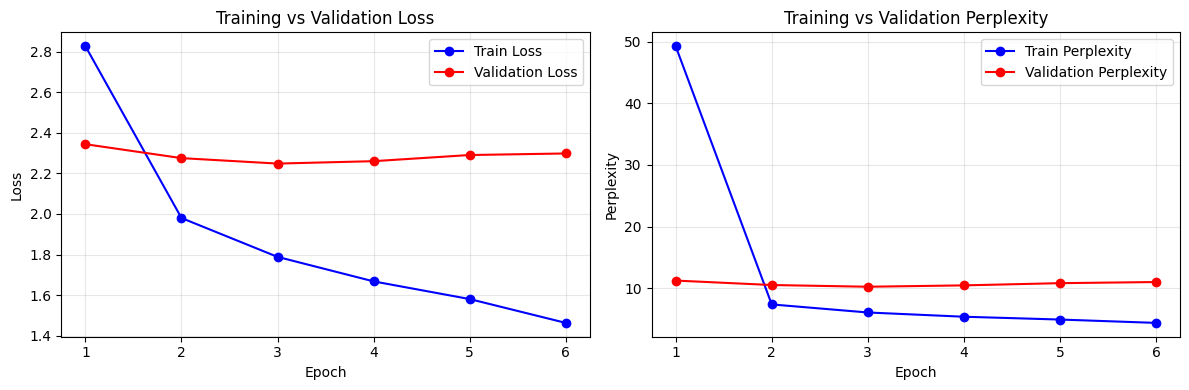

In [27]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_perplexity = history.history['perplexity']
val_perplexity = history.history['val_perplexity']

epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, 'b-', label='Train Loss', marker='o')
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_perplexity, 'b-', label='Train Perplexity', marker='o')
ax2.plot(epochs, val_perplexity, 'r-', label='Validation Perplexity', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.set_title('Training vs Validation Perplexity')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
training_history = {
    'epoch': list(range(1, len(history.history['loss']) + 1)),
    'train_loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'train_ppl': [float(x) for x in history.history['perplexity']],
    'val_ppl': [float(x) for x in history.history['val_perplexity']]
}

with open('training_hist.json', 'w') as f:
    json.dump(training_history, f, indent=2)

## 13. Evaluasi Kualitatif

Visualisasi prediksi caption pada 5 sampel gambar _test set_ secara acak. Setiap gambar ditampilkan bersama _true captions (ground truth)_ dan _predicted caption_ dari model.

In [29]:
def generate_caption(model, image_features, tokenizer, max_length):
    in_text = 'startseq'
    
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        
        yhat = model.predict([image_features, sequence], verbose=0)
        yhat = np.argmax(yhat)
        
        word = None
        for w, idx in tokenizer.word_index.items():
            if idx == yhat:
                word = w
                break
        
        if word is None or word == 'endseq':
            break
        
        in_text += ' ' + word

    final_caption = in_text.replace('startseq', '').strip()
    
    if final_caption and final_caption[-1] not in '.!?':
        final_caption += '.'
    
    return final_caption

In [ ]:
def display_predictions(
    dataframe,
    model,
    tokenizer,
    img_features_dict,
    max_length,
    num_samples=5,
    seed=42,
    figsize=(10, 8)
):
    df = dataframe.reset_index(drop=True)

    path_col = None
    for col in ['image_path', 'filepath', 'path']:
        if col in df.columns:
            path_col = col
            break
    
    if path_col is None:
        print(f"ERROR: No image path column found! Columns: {df.columns.tolist()}")
        return

    caption_col = None
    for col in ['caption', 'captions']:
        if col in df.columns:
            caption_col = col
            break
    
    unique_images = df[path_col].unique()
    
    np.random.seed(seed)
    sample_indices = np.random.choice(len(unique_images), min(num_samples, len(unique_images)), replace=False)
    sample_paths = unique_images[sample_indices]
    
    for i, img_path in enumerate(sample_paths, 1):
        print("-" * 110)
        print(f"Sample {i}/{num_samples}")
        
        try:
            pil_img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"ERROR loading image {img_path}: {e}")
            continue

        true_captions = df[df[path_col] == img_path][caption_col].tolist()

        if img_path not in img_features_dict:
            print(f"ERROR: Features not found for {img_path}")
            continue
        
        img_feature = img_features_dict[img_path]

        pred_caption = generate_caption(model, img_feature, tokenizer, max_length)
        
        img_name = img_path.split('/')[-1]
        print(f"Image: {img_name}")
        
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.imshow(pil_img)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()
        
        print(f"\nTrue Captions:")
        for j, cap in enumerate(true_captions[:5], 1):
            cap_clean = cap.replace('startseq', '').replace('endseq', '').strip()
            print(f"  {j}. {cap_clean}")
        
        print(f"\nPredicted Caption: {pred_caption}")

--------------------------------------------------------------------------------------------------------------
Sample 1/5
Image: mediumresidential_56.jpg


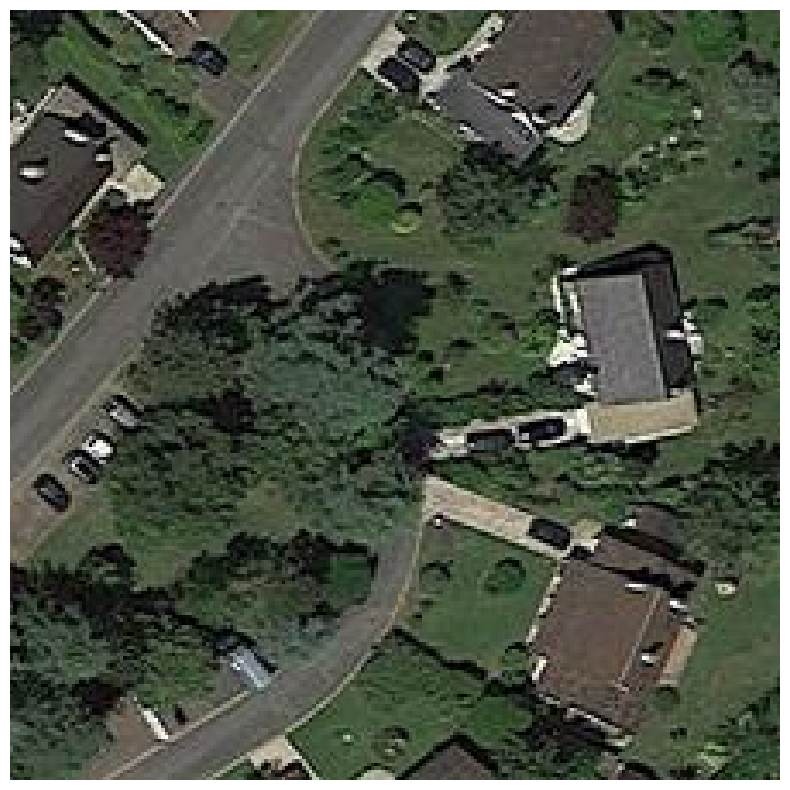


True Captions:
  1. on both sides of the road is a high quality residential area
  2. many trees were planted around the houses with grey roofs
  3. Many green blocks are located in the midum residential area
  4. many green blocks are in the midum residential area
  5. on both sides of the road is a high-grade residential area

Predicted Caption: many green buildings and trees are located in an average residential area.
--------------------------------------------------------------------------------------------------------------
Sample 2/5
Image: beach_61.jpg


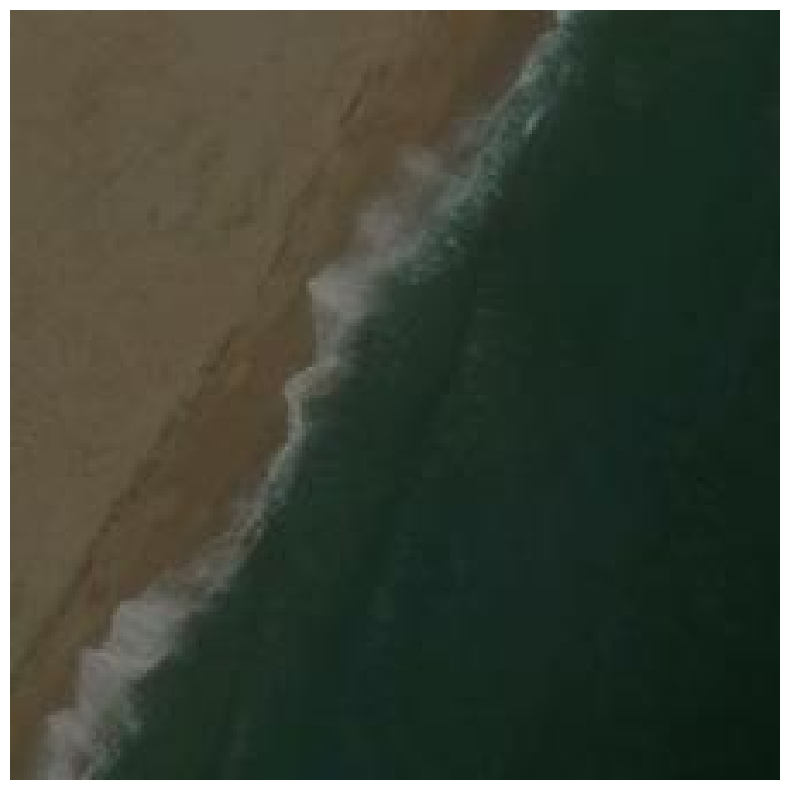


True Captions:
  1. in front of the sea is a vast beach the sea beats the wide beach
  2. the sea is beating the wide beach  facing the sea is a wide beach
  3. in front of the sea is a vast beach

Predicted Caption: a piece of ocean is near a yellow beach.
--------------------------------------------------------------------------------------------------------------
Sample 3/5
Image: baseballfield_62.jpg


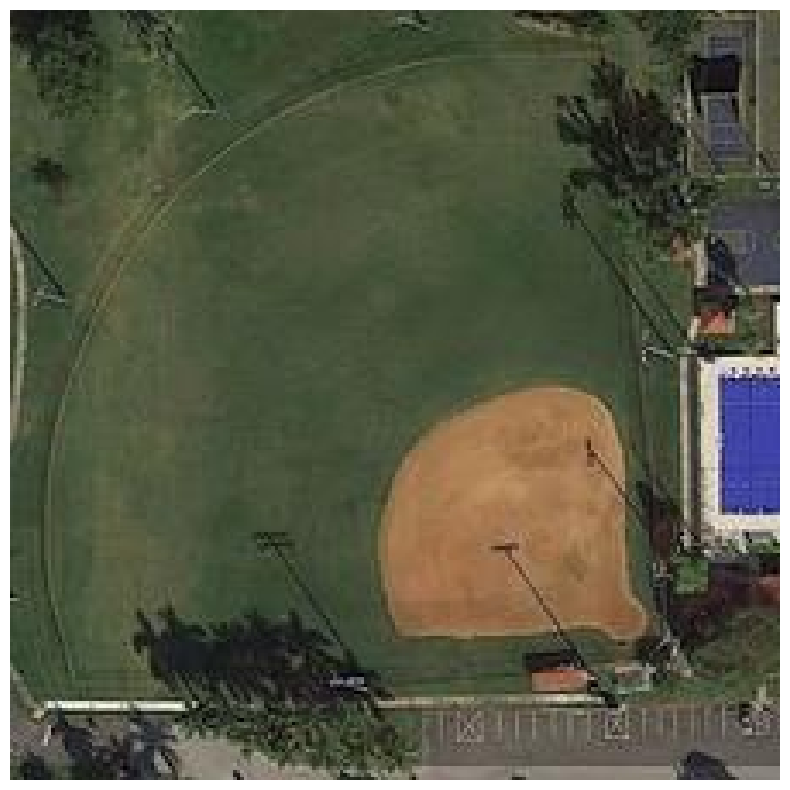


True Captions:
  1. the baseball field is next to a basketball field a volleyball court and a tennis court
  2. a parking lot is lying near the baseballfield next to which there are some other sports courts
  3. a fanshaped baseball field beside a basketball court and a tennis court
  4. a fan shaped baseballfield is surrounded by a basketball court several tennis courts and a parking lot
  5. several green trees are around a baseball field

Predicted Caption: a baseball field is surrounded by some green trees and a road.
--------------------------------------------------------------------------------------------------------------
Sample 4/5
Image: school_58.jpg


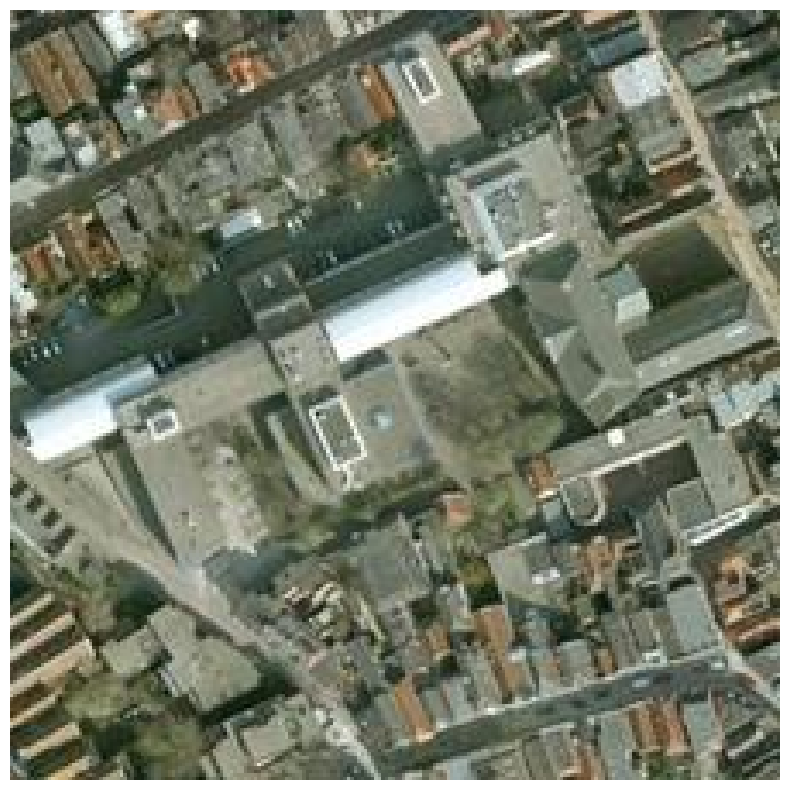


True Captions:
  1. The dense houses are close to each other
  2. the dense houses is close to each other
  3. a large teaching building lies in this school surrounded by dense residential houses
  4. many gray buildings and some trees are in a school

Predicted Caption: many buildings and some green trees are located in a commercial area.
--------------------------------------------------------------------------------------------------------------
Sample 5/5
Image: railwaystation_56.jpg


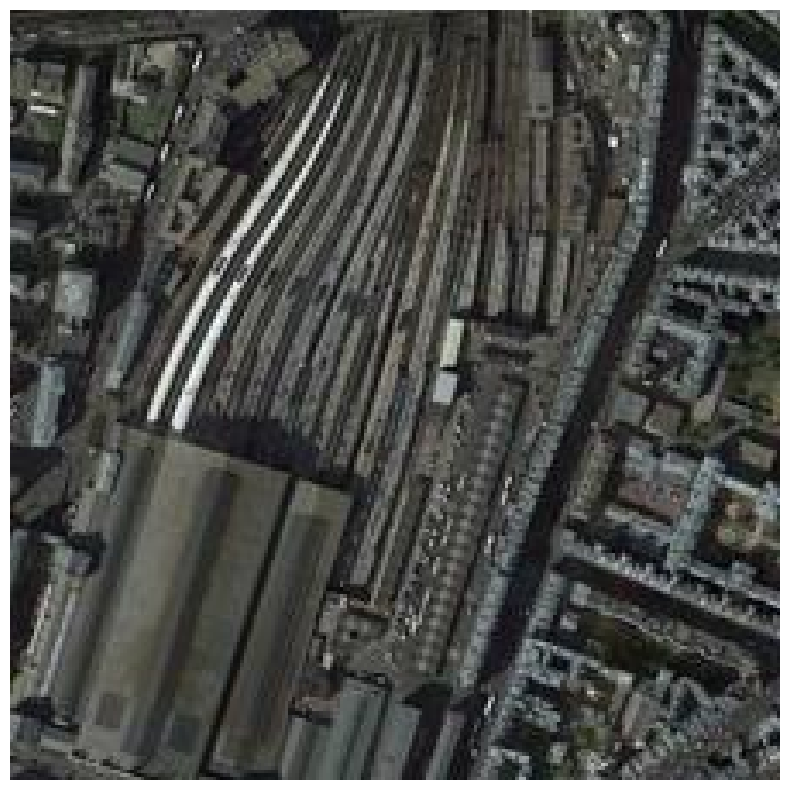


True Captions:
  1. The huge grey ceiling is above the rails
  2. The huge grey roof is on the rails
  3. the huge gray ceiling is over the rails
  4. two white trains are driving in this railway station next to a bustling road and buildings
  5. many gray buildings are in two sides of a railway station

Predicted Caption: many buildings and some green trees are located in a commercial area.


In [33]:
display_predictions(
    dataframe=test_data,
    model=caption_model,
    tokenizer=tokenizer,
    img_features_dict=test_img_features,
    max_length=max_length,
    num_samples=5,
    seed=42
)

## 14. Evaluasi Kuantitatif

Evaluasi kuantitatif pada seluruh _test set_ (1.093 gambar unik) menggunakan _metrics image captioning_ standar:
- **BLEU-1~4**: presisi n-gram antara _predicted_ dan _reference captions_
- **METEOR**: mengukur keselarasan semantik dengan _stemming_ dan _synonymy_
- **ROUGE-L**: _longest common subsequence_ antara _predicted_ dan _reference_
- **CIDEr**: _consensus-based metric_ yang memberi bobot pada kata-kata informatif

In [34]:
def generate_all_predictions(model, test_df, tokenizer, img_features_dict, max_length):
    path_col = None
    for col in ['image_path', 'filepath', 'path']:
        if col in test_df.columns:
            path_col = col
            break
    
    caption_col = None
    for col in ['caption', 'captions']:
        if col in test_df.columns:
            caption_col = col
            break
    
    unique_images = test_df[path_col].unique()
    
    predictions = {}
    references = {}
    
    print(f"Generating captions for {len(unique_images)} images.")
    
    for idx, img_path in enumerate(tqdm(unique_images, desc='Generating')):
        try:
            if img_path not in img_features_dict:
                continue
            
            img_feature = img_features_dict[img_path]    
            pred_caption = generate_caption(model, img_feature, tokenizer, max_length)
            true_captions = test_df[test_df[path_col] == img_path][caption_col].tolist()
            true_captions = [cap.replace('startseq', '').replace('endseq', '').strip().lower() for cap in true_captions]
            
            predictions[idx] = [pred_caption.lower()]
            references[idx] = true_captions
            
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    return predictions, references


In [35]:
def compute_metrics(predictions, references):
    print("\nComputing metrics.")
    
    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Meteor(), "METEOR"),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr"),
    ]
    
    results = {}
    
    for scorer, method in scorers:
        try:
            score, scores = scorer.compute_score(references, predictions)
            
            if isinstance(method, list):
                for m, s in zip(method, score):
                    results[m] = s * 100
                    print(f"  {m}: {s * 100:.2f}")
            else:
                results[method] = score * 100
                print(f"  {method}: {score * 100:.2f}")
                
        except Exception as e:
            print(f"  Error computing {method}: {e}")
    
    return results

In [37]:
predictions, references = generate_all_predictions(
    model=caption_model,
    test_df=test_data,
    tokenizer=tokenizer,
    img_features_dict=test_img_features,
    max_length=max_length
)

results = compute_metrics(predictions, references)

Generating captions for 1093 images.


Generating: 100%|██████████| 1093/1093 [42:39<00:00,  2.34s/it]



Computing metrics.
{'testlen': 11722, 'reflen': 11733, 'guess': [11722, 10629, 9536, 8443], 'correct': [6526, 2866, 1470, 768]}
ratio: 0.9990624733656355
  BLEU-1: 55.62
  BLEU-2: 38.71
  BLEU-3: 28.47
  BLEU-4: 21.40
  METEOR: 23.84
  ROUGE-L: 41.36
  CIDEr: 36.03


## 15. Hasil Metrik Evaluasi

Hasil evaluasi akhir model **ViT-BiLSTM** pada _test set_:

| Metric | Score |
|--------|-------|
| BLEU-1 | 55.62 |
| BLEU-2 | 38.71 |
| BLEU-3 | 28.47 |
| BLEU-4 | 21.40 |
| METEOR | 23.84 |
| ROUGE-L | 41.36 |
| CIDEr | 36.03 |